In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raw_data = pd.read_csv("../raw_data/nfl_odds_2007-2022.csv", parse_dates=["date"])
raw_data.shape

(4025, 12)

### Away ML

In [4]:
raw_data['away_ml'].describe()

count    4025.000000
mean       74.409441
std       303.669518
min     -2500.000000
25%      -150.000000
50%       140.000000
75%       240.000000
max      2173.000000
Name: away_ml, dtype: float64

In [8]:
#outliers
q1_aml, q3_aml =  raw_data['away_ml'].quantile([.25, .75])
iqr_aml = q3_aml - q1_aml
lower_aml, upper_aml = q1_aml - 1.5 * iqr_aml, q3_aml + 1.5 * iqr_aml
outliers_aml = raw_data[~raw_data['away_ml'].between(lower_aml, upper_aml)]
outliers_aml['away_ml']


36      1350
68      1050
93     -1700
114     1000
145     1000
        ... 
3956    -800
3969    -750
3982   -1000
3988     900
4001   -1100
Name: away_ml, Length: 83, dtype: int64

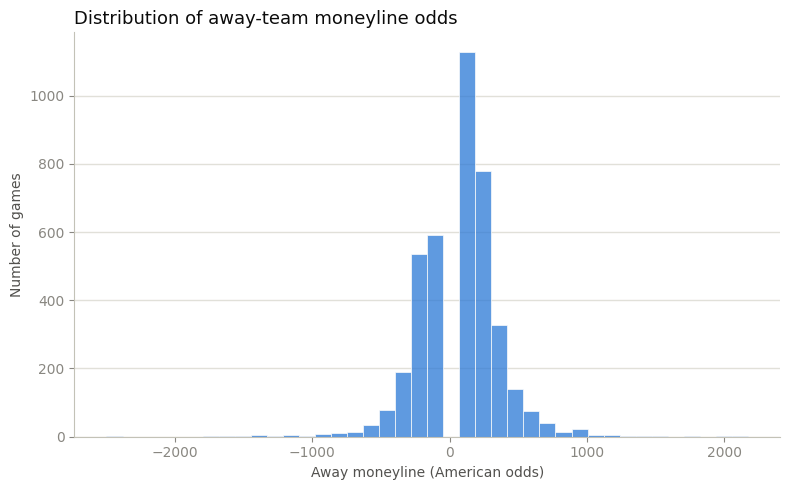

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=raw_data,
    x="away_ml",
    bins=40,
    color="#2a78d6",       # single series -> one hue, no legend needed
    edgecolor="#fcfcfb",   # thin surface-colored edge separates adjacent bins
    linewidth=0.5,
    ax=ax,
)

ax.set_title("Distribution of away-team moneyline odds", loc="left", fontsize=13, color="#0b0b0b")
ax.set_xlabel("Away moneyline (American odds)", color="#52514e")
ax.set_ylabel("Number of games", color="#52514e")
ax.tick_params(colors="#898781")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Home ML Eda

In [7]:
raw_data['home_ml'].describe()

count    4025.000000
mean     -148.743354
std       378.210495
min     -5000.000000
25%      -295.000000
50%      -160.000000
75%       130.000000
max      1100.000000
Name: home_ml, dtype: float64

In [13]:
raw_data[raw_data['home_ml'] == -5000]

,date,away_team,home_team,away_score,home_score,away_ml,home_ml,open_spread,close_spread,open_total,close_total,season
1689,2013-10-13,Jacksonville,Denver,19,35,2173,-5000,24.0,26.5,47.0,52.5,2013-14
3244,2019-09-22,Miami,Dallas,6,31,1500,-5000,17.0,22.5,47.0,46.5,2019-20
3582,2020-11-01,NYJets,KansasCity,9,35,1500,-5000,21.0,19.5,47.5,49.0,2020-21


The -5000 odds seem very unlikely but these made sense given the away_ml matching. -5000 seems to be a market cap on odds but even though they are extreme outliers they are real odds for very one-sided matchups so they will not be removed

In [9]:
#outliers
q1_hml, q3_hml = raw_data['home_ml'].quantile([.25, .75])
iqr_hml = q3_hml - q1_hml
lower_hml , upper_hml = q1_hml - 1.5 * iqr_hml , q3_hml + 1.5 * iqr_hml
outliers_hml = raw_data[~raw_data['home_ml'].between(lower_hml, upper_hml)]
outliers_hml['home_ml']

36     -2200
58     -1000
68     -1600
93      1100
114    -1500
        ... 
3852     800
3867     800
3983   -1000
3988   -1600
4002   -1400
Name: home_ml, Length: 111, dtype: int64

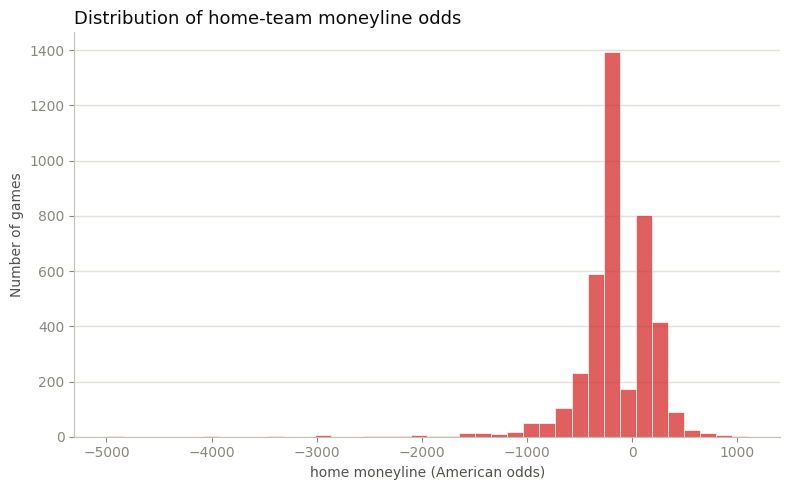

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=raw_data,
    x="home_ml",
    bins=40,
    color="#d62a2a",       # single series -> one hue, no legend needed
    edgecolor="#fcfcfb",   # thin surface-colored edge separates adjacent bins
    linewidth=0.5,
    ax=ax,
)

ax.set_title("Distribution of home-team moneyline odds", loc="left", fontsize=13, color="#0b0b0b")
ax.set_xlabel("home moneyline (American odds)", color="#52514e")
ax.set_ylabel("Number of games", color="#52514e")
ax.tick_params(colors="#898781")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()